In [1]:
import stackview as st
import numpy as np
import pandas as pd
import os
import glob
import json
from copy import deepcopy as cp

from tifffile import imread
import skimage.util as util
import skimage.exposure as exp
import skimage.color as col
import skimage.restoration as rest
import skimage.transform as trans
import skimage.graph as gra
import skimage.segmentation as seg
import skimage.filters as filt
import skimage.morphology as morph

import scipy.signal as sig
import scipy.ndimage as ndi

import matplotlib.pyplot as plt
import networkx as nx

from pyfibre.fibers.metrics import fibre_network_metrics, fibre_metrics
from pyfibre.fibers.analysis import network_analysis
from pyfibre.fibers.network_extraction import fibre_network_assignment
from pyfibre.fibers.fibre_network import FibreNetwork

In [2]:
example_dir = "/home/vpc/Pictures/Exemplo_Picro/"
example_output_dir = os.path.join(example_dir, 'Saída')

os.makedirs(example_output_dir, exist_ok=True)

In [ ]:
img_path = os.path.join(example_dir, 'imagem.tif')
img = imread(img_path).astype('float32')

red, green, _ = np.unstack(img, axis=-1)
rg = np.divide((red+green), 2)

In [4]:
opt_params = {
    "scale": 0.25, "angle_thresh": 70, "r_thresh": 14, "sigma": 2, "return_img": True
}

In [5]:
ci, network = network_analysis(rg, p_denoise=(3,40), **opt_params)
networks = fibre_network_assignment(network)

print(f"Raw graph: {network.number_of_nodes()} nodes, {network.number_of_edges()} edges")
print(f"Found {len(networks)} sub-networks of interconnected nodes")

Raw graph: 7737 nodes, 7800 edges
Found 155 sub-networks of interconnected nodes


[[4.  4.  6.5 ... 6.5 7.5 7.5]
 [4.  4.  6.5 ... 6.5 7.5 7.5]
 [6.  6.  4.  ... 7.  7.  7. ]
 ...
 [3.5 3.5 3.5 ... 7.  8.  8. ]
 [4.5 4.5 2.5 ... 7.5 7.  7. ]
 [4.5 4.5 2.5 ... 7.5 7.  7. ]]
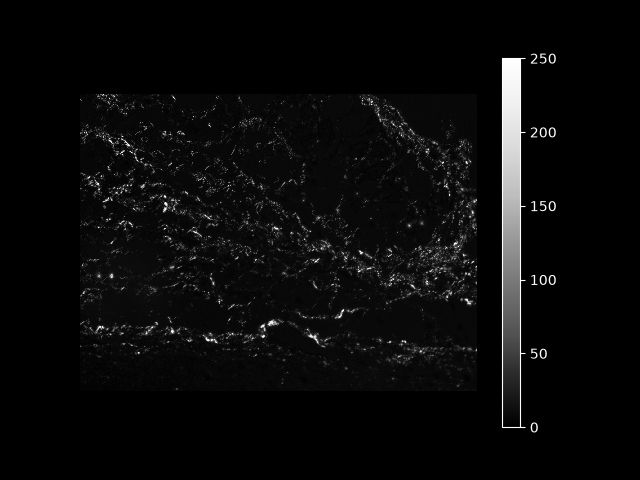
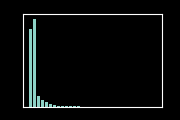

In [81]:
st.insight(rg)

In [97]:
dummy_networks = [ networks[j] for j in [77, 24, 32, 135]]

dummy = np.zeros_like(rg)

for j, network in enumerate(dummy_networks):
    print(f"NETWORK {j}")
    fibers = network.generate_fibres()
    for i, fiber in enumerate(fibers):
        print(f"FIBER {i}")
        node_coords = fiber.node_coord
        for node in node_coords:
            print(node)
            dummy[node[0], node[1]] = 1
            

NETWORK 0
FIBER 0
[ 384 1200]
[ 392 1196]
[ 400 1196]
[ 408 1196]
[ 412 1200]
[ 416 1200]
[ 436 1192]
FIBER 1
[ 436 1152]
[ 436 1156]
[ 436 1164]
[ 436 1172]
[ 436 1192]
[ 416 1200]
[ 412 1200]
NETWORK 1
FIBER 0
[ 80 588]
[ 80 584]
[ 72 572]
[ 72 564]
[ 68 560]
NETWORK 2
FIBER 0
[1120  784]
[1120  776]
[1116  772]
[1116  768]
[1128  752]
NETWORK 3
FIBER 0
[1112  200]
[1112  192]
[1104  184]
[1096  176]
[1076  180]
[1068  180]
[1064  180]
[1060  180]
[1052  176]
[1044  172]
[1036  172]
[1024  168]
FIBER 1
[1000  312]
[1004  312]
[1020  308]
[1024  304]
[1028  296]
[1028  288]
[1028  280]
[1024  272]
[1024  264]
[1012  248]
[1012  244]
[1012  236]
[1008  216]
[1012  212]
[1016  204]
[1024  200]
[1024  192]
[1024  176]
[1024  168]
[1024  160]
[1020  156]
[1020  152]
[1008  132]
FIBER 2
[1024  348]
[1024  340]
[1024  336]
[1024  332]
[1020  312]
[1020  308]
[1024  304]
[1028  296]
[1028  288]
[1028  280]
[1024  272]
[1024  264]
[1012  248]
[1012  244]
[1012  236]
[1008  216]
[1012  212]
[1

In [101]:
st.curtain(morph.dilation(dummy, footprint=morph.disk(2)), rg)

[[[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  ...
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]]

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  ...
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]]

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  ...
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]]

 ...

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  ...
  [0.14509805 0.25490198 0.18039216]
  [0.20784314 0.34901962 0.19607843]
  [0.20784314 0.34901962 0.19607843]]

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  ...
  [0.1882353  0.35686275 0.19607843]
  [0.23137255 0.34901962 0.18431373]
  [0.23137255 0.34901962 0.18431373]]

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  ...
  [0.1882353  0.35686275 0.19607843]
  [0.23137255 0.34901962 0.18431373]
  [0.23137255 0.34901962 0.18431373]]]
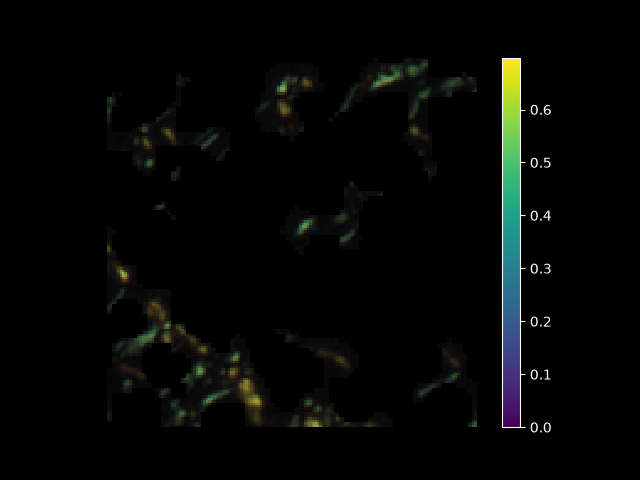
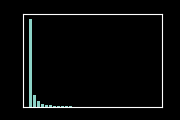

In [48]:
ci_mm = (ci - ci.min()) / (ci.max() - ci.min())
ci_mm = ci_mm > filt.threshold_otsu(ci_mm)
ci_mm = trans.rescale(ci_mm, 4, mode='constant')
im_n = img / 255.0

chs = []
for i in range(3):
    ch = im_n[..., i]
    mch = ch * ci_mm
    chs.append(mch)

im_mk = np.stack(chs, axis=-1)

st.insight(im_mk[300:600, 1000:1300])

In [297]:
network_metrics = fibre_network_metrics(networks)

In [92]:
network_metrics.keys()

Index(['No. Fibres', 'Fibre Angle SDI', 'Mean Fibre Waviness',
       'Mean Fibre Length', 'Fibre Network Cross-Link Density',
       'Fibre Network Degree', 'Fibre Network Eigenvalue',
       'Fibre Network Connectivity'],
      dtype='str')

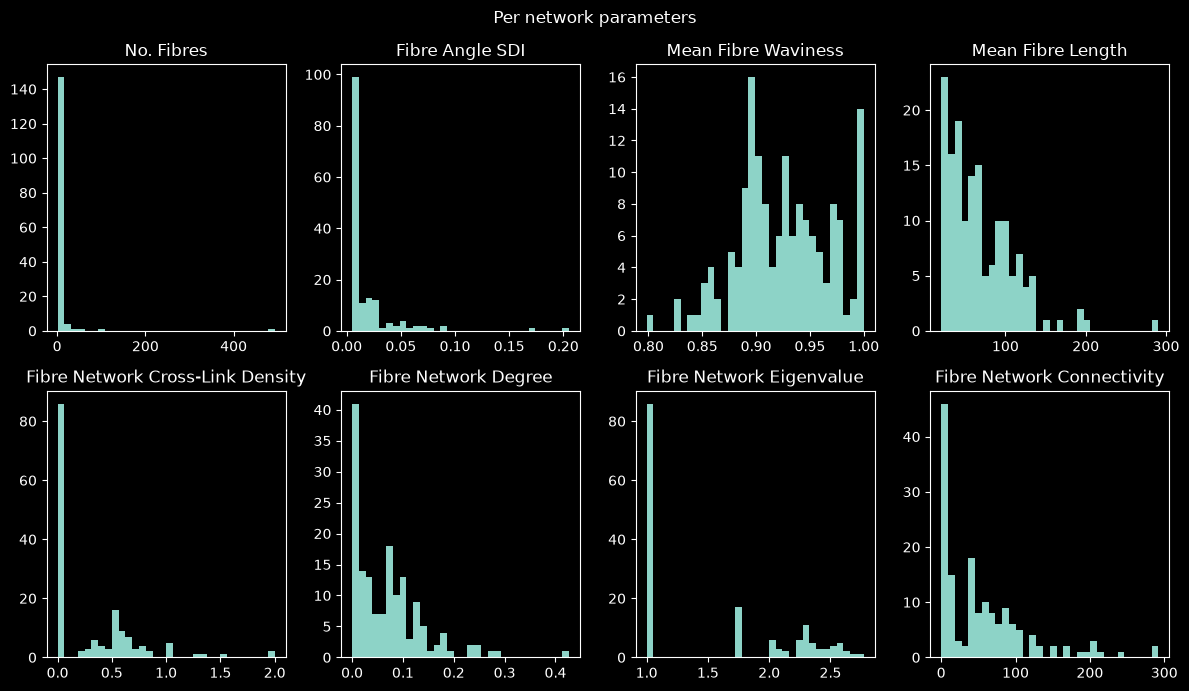

In [298]:
fig, ax = plt.subplots(2,4, figsize=(12,7))

ax = ax.ravel()

for j, key in enumerate(network_metrics.keys()):
    ax[j].hist(network_metrics[key], bins=32)
    ax[j].set_title(key)
    
plt.suptitle("Per network parameters")
plt.tight_layout()
plt.show()
plt.close()

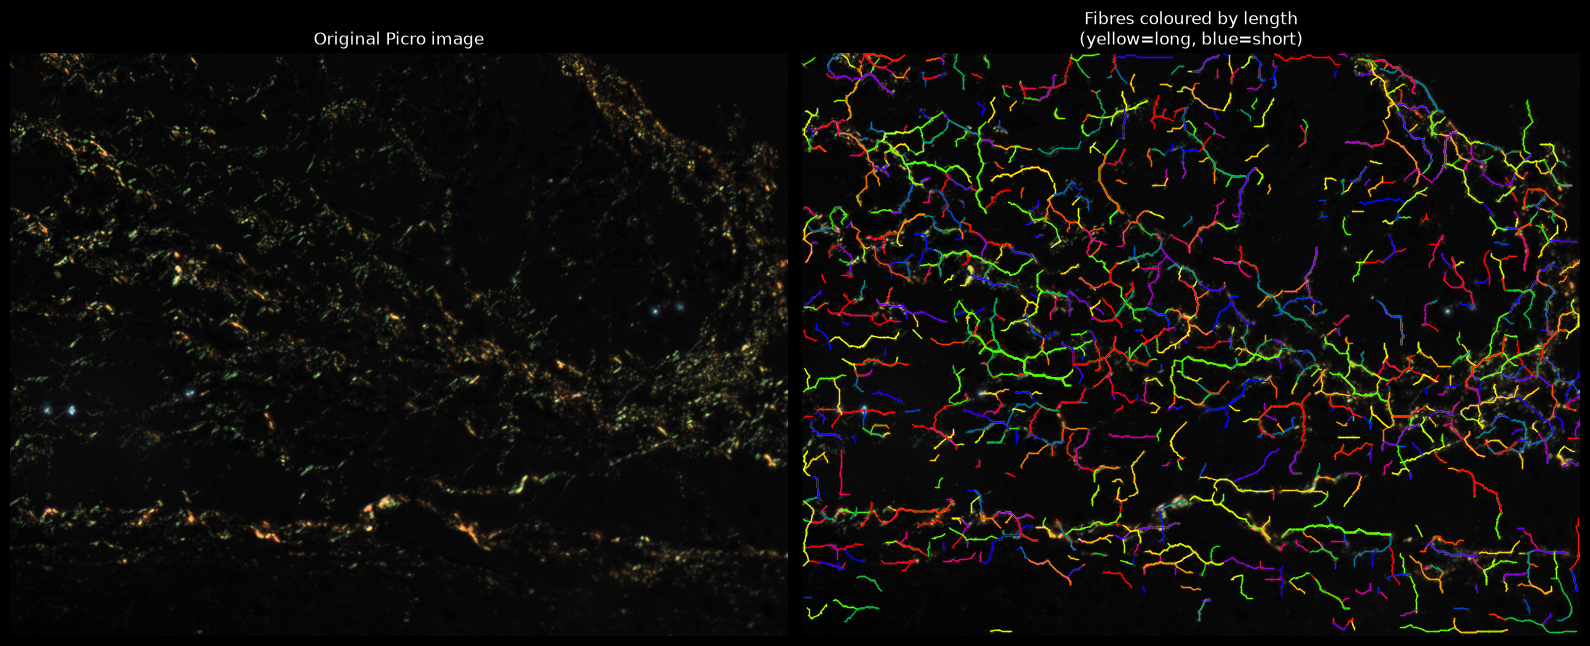

In [314]:
fig, axes = plt.subplots(1, 2, figsize=(16, 16))

# 1) Original
axes[0].imshow(img / 255.0)
axes[0].set_title('Original Picro image', fontsize=12)
axes[0].axis('off')

# 4) Colour by fibre length
from matplotlib.colors import Normalize
max_len = max(metrics['Mean Fibre Length'].to_list())

cmap = plt.cm.prism
norm = Normalize(vmin=0, vmax=max_len)
image_height, image_width = rg.shape

axes[1].imshow(img / 255.0)
for netw in networks:
    for fibre in netw.generate_fibres():
        flen = fibre.fibre_l
        color = cmap(norm(flen))[:3]
        for u, v in fibre.graph.edges():
            y1, x1 = fibre.graph.nodes[u]['xy']
            y2, x2 = fibre.graph.nodes[v]['xy']
            axes[1].plot(
                [x1, x2], [y1, y2],
                color=color, linewidth=1
        )
            
axes[1].set_ylim(image_height, 0)
axes[1].set_xlim(0, image_width)
axes[1].set_aspect('equal')
axes[1].set_title('Fibres coloured by length\n(yellow=long, blue=short)', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
from pyfibre.tools.preprocessing import nl_means, clip_intensities
rg_f = rg / 255.0

rg_norm = clip_intensities(rg_f, (1, 99))
rg_eq = exp.equalize_adapthist(rg_norm)

sig = rest.estimate_sigma(rg_eq)

dn_params = {
    'patch_size': np.arange(1, 8, 2),
    'patch_distance': np.arange(20, 45, 5),
    'h': [1.2 * sig],
    'sigma': [sig],
    'fast_mode': [True]
}

_, (test_params, test_losses) = rest.calibrate_denoiser(
    rg_eq, rest.denoise_nl_means, dn_params, extra_output=True
)

best_idx = np.argmin(test_losses)
best_params = test_params[best_idx]

for j, params in enumerate(test_params):
    s = params['patch_size']
    d = params['patch_distance']

    if s == 5 and d == 35:
        def_idx = j

def_params = test_params[def_idx]
rg_eq_dn = rest.denoise_nl_means(rg_eq, **best_params)
rg_eq_dn_def = rest.denoise_nl_means(rg_eq, **def_params)

pss = np.array(
    [ d['patch_size'] for d in test_params ]
)
pds = np.array(
    [ d['patch_distance'] for d in test_params ]
)
loss = np.array(
    test_losses
)

pss_ = np.unique(pss)
pds_ = np.unique(pds)
loss_ = loss.reshape(len(pss_), len(pds_))

/tmp/ipykernel_52846/507442424.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  graph_ax.legend()


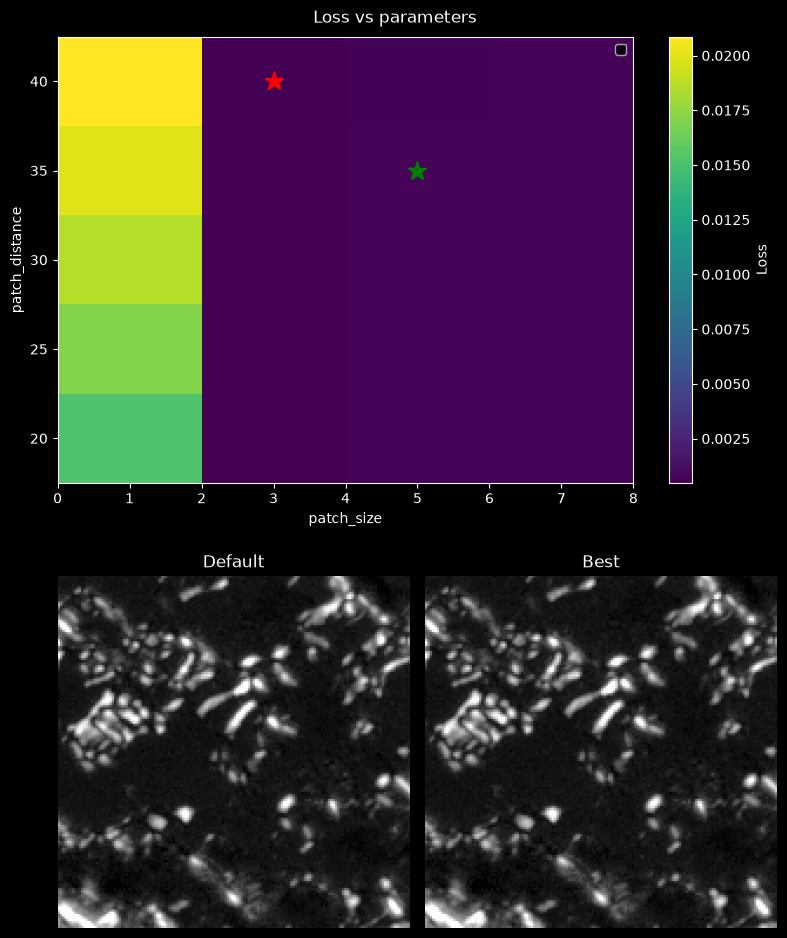

In [294]:
fig = plt.figure(figsize=(8,10), layout='tight')
plt.suptitle("Loss vs parameters")

graph_ax = plt.subplot(211)
img_ax = plt.subplot(223)
img_dn_ax = plt.subplot(224)

graph_ax.set_xlabel('patch_size')
graph_ax.set_ylabel('patch_distance')
graph_ax.legend()

# Try pcolormesh first (handles irregular grids); fall back to imshow for regular
P1, P2 = np.meshgrid(pss_, pds_, indexing='ij')
c = graph_ax.pcolormesh(
    P1, P2, loss_,
    shading='auto', cmap='viridis'
)

fig.colorbar(c, ax=graph_ax, label='Loss')

# Mark the minimum
i_min, j_min = np.unravel_index(np.argmin(loss_), loss_.shape)
graph_ax.plot(
    pss_[i_min], pds_[j_min],
    'r*', markersize=14, label='Best'
)

i_def, j_def = np.unravel_index(13, loss_.shape)
graph_ax.plot(
    pss_[i_def], pds_[j_def],
    'g*', markersize=14, label='Default'
)

[ a.axis('off') for a in [ img_ax, img_dn_ax ] ]

plt.set_cmap('gray')

img_ax.imshow(
    rg_eq_dn_def[500:800, 800:1100]
    )
img_ax.set_title("Default")

img_dn_ax.imshow(
    rg_eq_dn[500:800, 800:1100]
)
img_dn_ax.set_title("Best")

plt.show()
plt.close()

[13, 5611, 6661, 1662]

In [ ]:
img_r = rg
img_sato = filt.sato(
    img_r,
    sigmas=range(1, 4),
    black_ridges=False,
    mode='constant'
)

st.blend(img_r, img_sato)

In [ ]:

low = np.min([
    filt.threshold_mean(img_sato), filt.threshold_li(img_sato)
])

high = filt.threshold_isodata(img_sato)
otsu = filt.threshold_otsu(img_sato)
img_t = filt.apply_hysteresis_threshold(img_sato, low, otsu)
img_tc = morph.remove_small_objects(img_t, max_size=64)
img_ds = ndi.distance_transform_edt(img_tc)
img_sm = ndi.gaussian_filter(img_ds, sigma=0.5)

In [51]:
img_sm_t = img_sm > filt.threshold_otsu(img_sm)

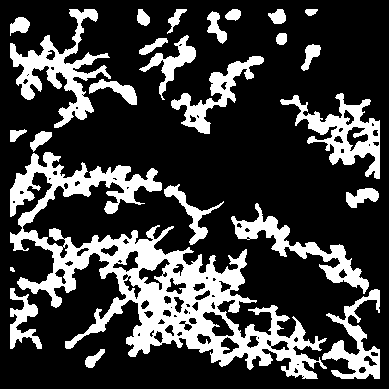

In [84]:
st.imshow(img_t[400:800, 400:800])

In [427]:
img_f = cp(img) / 255

In [436]:
#t_sato = morph.remove_small_objects(img_sato > otsu, max_size=64)

mask = np.stack(
    [ img_f[..., i] * img_sm_t for i in range(3) ],
    axis=-1
)

[(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5)),
 (np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))]

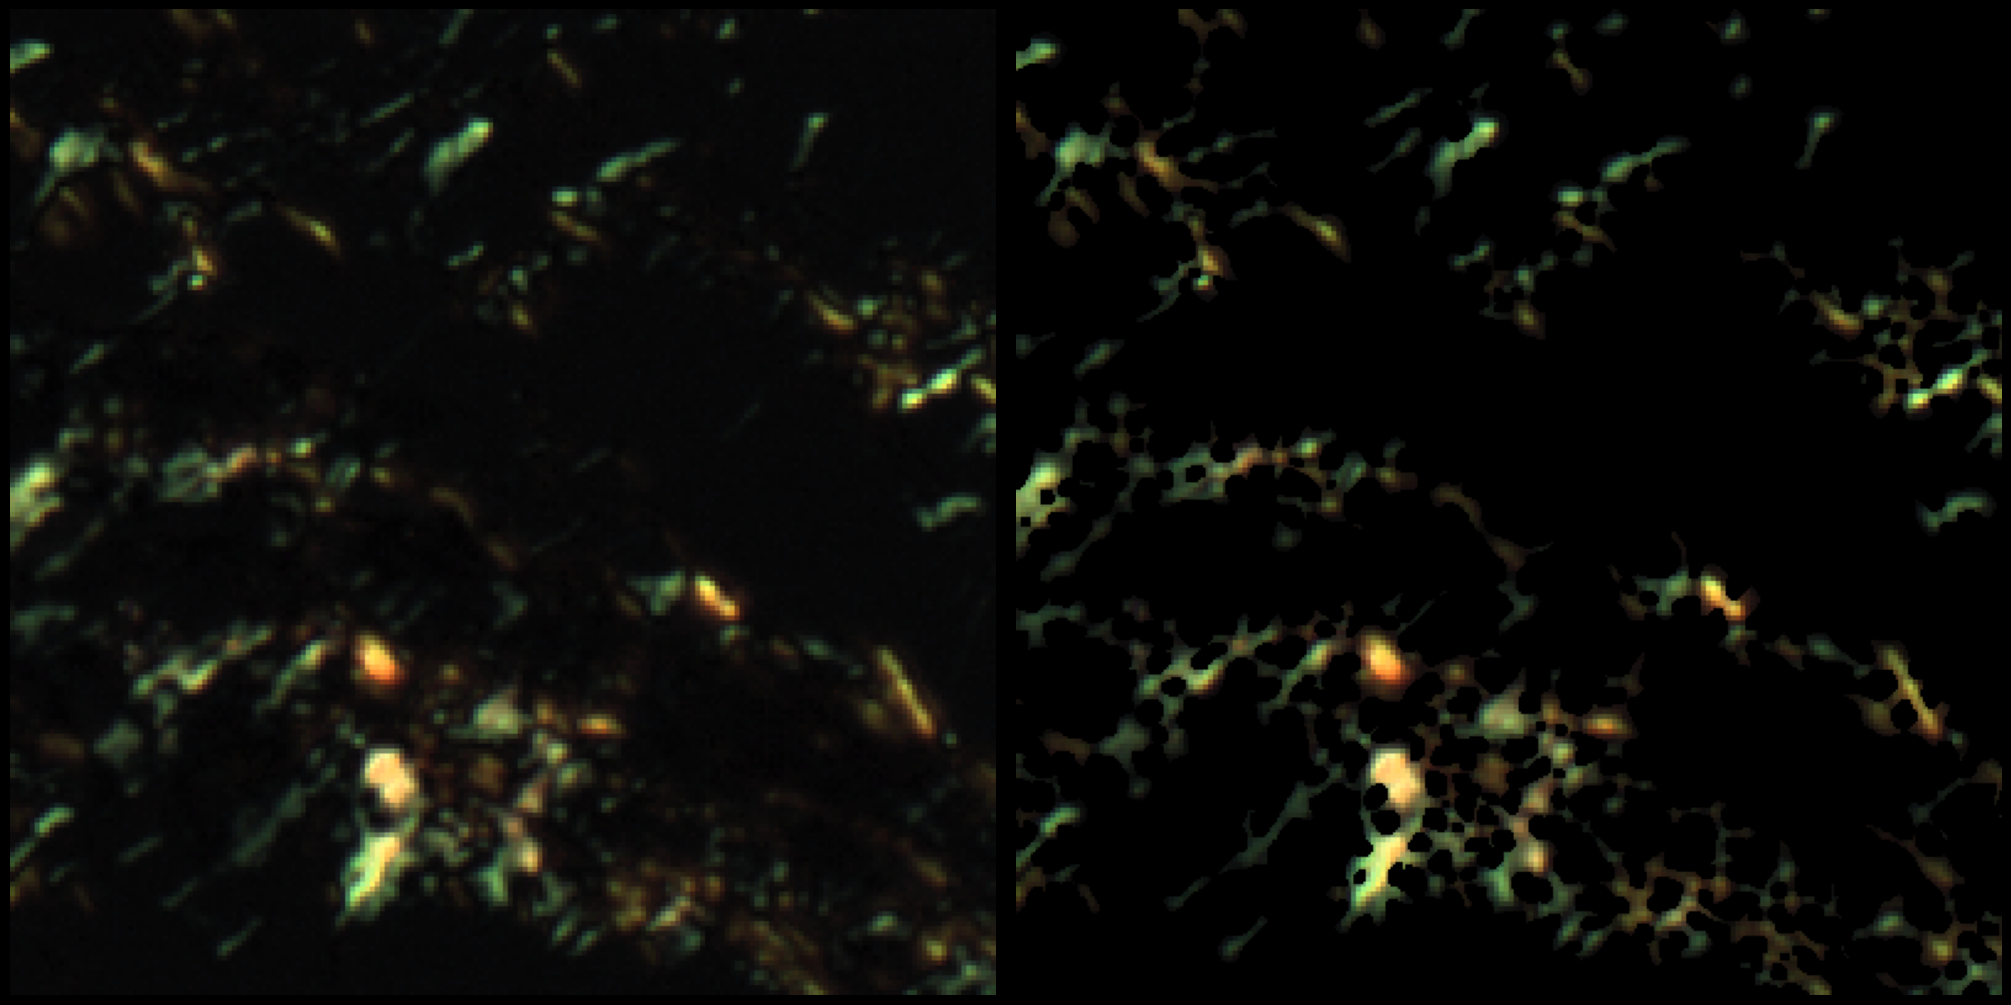

In [438]:
fig, ax = plt.subplots(1,2, figsize=(20,10), layout='constrained')
ax[0].imshow(img_f[400:800, 400:800])
ax[1].imshow(mask[400:800, 400:800])

[a.axis('off') for a in ax]